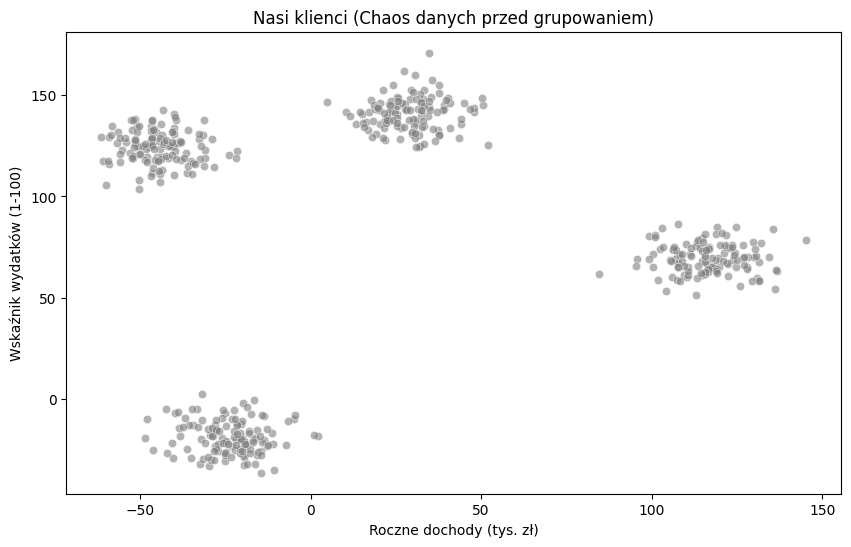

,Roczne_dochody_tys,Wskaznik_wydatkow_1_100
0,-35.0,117.6
1,-48.4,-19.2
2,136.7,63.3
3,26.1,128.4
4,-11.0,-22.1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Generujemy sztuczne dane, które naturalnie układają się w 4 grupy
# (Ale my udamy, że tego nie wiemy i każemy modelowi zgadnąć!)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

# Przekształcamy to na realnie wyglądające liczby
# Oś X: Roczne dochody w tys. zł (np. od 30 do 120 tys.)
dochody = X[:, 0] * 12 + 60 
# Oś Y: Wskaźnik wydatków od 1 do 100 (jak chętnie wydają pieniądze)
wydatki = X[:, 1] * 10 + 50 

df_klienci = pd.DataFrame({
    'Roczne_dochody_tys': np.round(dochody, 1),
    'Wskaznik_wydatkow_1_100': np.round(wydatki, 1)
})

# Wyświetlamy jak wyglądają dane przed wejściem sztucznej inteligencji
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_klienci, x='Roczne_dochody_tys', y='Wskaznik_wydatkow_1_100', color='gray', alpha=0.6)
plt.title('Nasi klienci (Chaos danych przed grupowaniem)')
plt.xlabel('Roczne dochody (tys. zł)')
plt.ylabel('Wskaźnik wydatków (1-100)')
plt.show()

display(df_klienci.head())

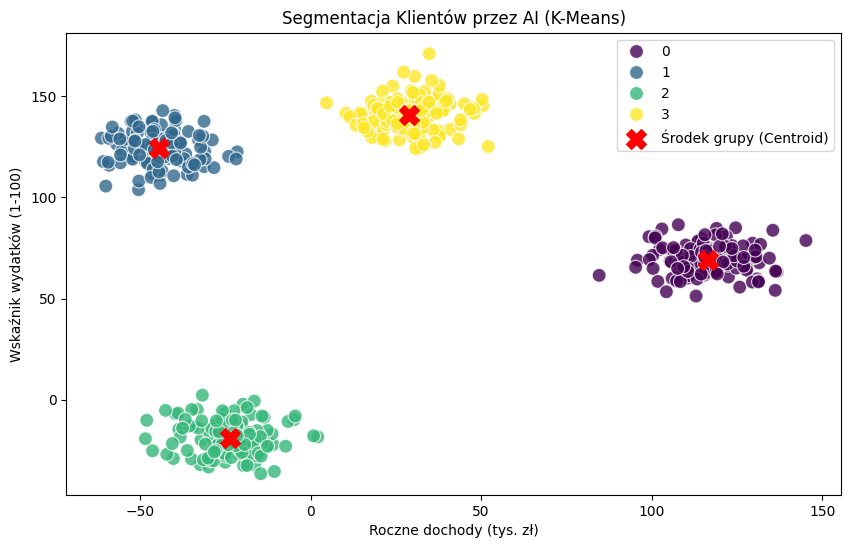

In [2]:
from sklearn.cluster import KMeans

# 1. Inicjalizacja modelu K-Means (prosimy o 4 grupy, bo tak zakładaliśmy w biznesplanie)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Trenowanie modelu i od razu przypisanie wyników (zauważ: podajemy tylko dane df_klienci!)
df_klienci['Segment_AI'] = kmeans.fit_predict(df_klienci)

# 3. Wyciągamy współrzędne środków naszych grup (centroidów)
centroidy = kmeans.cluster_centers_

# 4. Rysujemy piękny, biznesowy wykres
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_klienci, x='Roczne_dochody_tys', y='Wskaznik_wydatkow_1_100', 
                hue='Segment_AI', palette='viridis', s=100, alpha=0.8)

# Dorzucamy na wykres czerwone "X" oznaczające środki grup
plt.scatter(centroidy[:, 0], centroidy[:, 1], c='red', s=200, marker='X', label='Środek grupy (Centroid)')

plt.title('Segmentacja Klientów przez AI (K-Means)')
plt.xlabel('Roczne dochody (tys. zł)')
plt.ylabel('Wskaźnik wydatków (1-100)')
plt.legend()
plt.show()